# Regression & Its Evaluation

Question 1: What is Simple Linear Regression?

-> Simple linear regression is a statistical method used to model and quantify the relationship between two continuous quantitative variables: one independent variable (x) and one dependent variable (Y). The "simple" in its name refers to the fact that it involves only a single predictor variable.

Question 2: What are the key assumptions of Simple Linear Regression?

-> While the LINE mnemonic covers the basics, there are five formal assumptions required to ensure your model's predictions and statistical tests are reliable:

1. Linearity:

* The relationship between the independent variable (x) and the dependent variable (Y) must be linear. If the data follows a curve, a straight line will result in poor predictions.

* Check: Look at a scatter plot of x vs Y.

2. Independence of Observations:

* The data points must be independent of each other. This means the value of one observation shouldn't influence another. This is often a concern with time-series data (where today’s value depends on yesterday’s).

* Check: Look for patterns in a "residuals vs. time" plot or use the Durbin-Watson test.

3. Normality of Residuals:

* The errors (the vertical distances between the data points and the line) should be normally distributed. This is especially important if you want to calculate confidence intervals or p-values.

* Check: Use a Q-Q plot or a histogram of the residuals.

4. Homoscedasticity (Constant Variance):

* The variance of the residuals should be constant across all levels of X. In simple terms, the "spread" of the data points around the regression line should look roughly the same from beginning to end, rather than fanning out.

* Check: Look at a "residuals vs. fitted values" plot; it should look like a random cloud of points.

5. No Significant Outliers:

* Linear regression is highly sensitive to outliers. A single extreme data point can "pull" the line toward it, significantly altering the slope and intercept.

* Check: Use boxplots or leverage statistics to identify influential points.

Question 3: What is heteroscedasticity, and why is it important to address in regression models?

-> Heteroscedasticity occurs when the "noise" or error in a model isn't constant. Instead of the data points hugging the regression line consistently, the spread (variance) of the residuals changes as the value of the independent variable (X) ncreases or decreases. Visually, this often looks like a cone or fan shape on a scatter plot.

* Why it's important to address:

1. Unreliable Standard Errors: This is the biggest issue. Heteroscedasticity "breaks" the math used to calculate standard errors. If these are wrong, your p-values and confidence intervals become unreliable. You might conclude a variable is "statistically significant" when it actually isn't.

2. Inefficient Estimates: While the regression line itself (the slope) might still be unbiased, it is no longer the best or most precise estimate possible. You are essentially leaving "accuracy" on the table.

3. Flawed Hypothesis Testing: Because the spread is uneven, the model gives equal weight to all data points. In reality, points in the "wide" part of the fan are less certain than points in the "narrow" part.

Question 4: What is Multiple Linear Regression?

-> Multiple Linear Regression (MLR) is a statistical technique that models the relationship between one continuous dependent variable and two or more independent variables. While simple linear regression uses a single predictor to estimate an outcome, MLR allows you to understand how multiple factors collectively influence that outcome.

Question 5: What is polynomial regression, and how does it differ from linear regression?

-> Polynomial regression is a form of regression analysis where the relationship between the independent variable X and the dependent variable Y is modeled as an n-th degree polynomial. While it still uses the same underlying math as linear regression to find coefficients, it allows the "line" to curve to better fit non-linear data.

Key Differences:

1) Linear Regression

* Shape of Fit: A straight line.

* Relationship: Assumes the rate of change between X and Y is constant.

* Complexity: Simple and less prone to overfitting.

* Data Use: Best for simple, proportional trends.

2) Polynomial Regression

* Shape of Fit: A curved line.

* Relationship: Allows the rate of change to increase or decrease (non-linear).

* Complexity: More complex; can easily "overfit" by tracing noise instead of the trend.

* Data Use: Best for phenomena like growth rates, trajectories, or chemical reactions.

Slope (beta_1): 1.9800
Intercept (beta_0): 0.1800


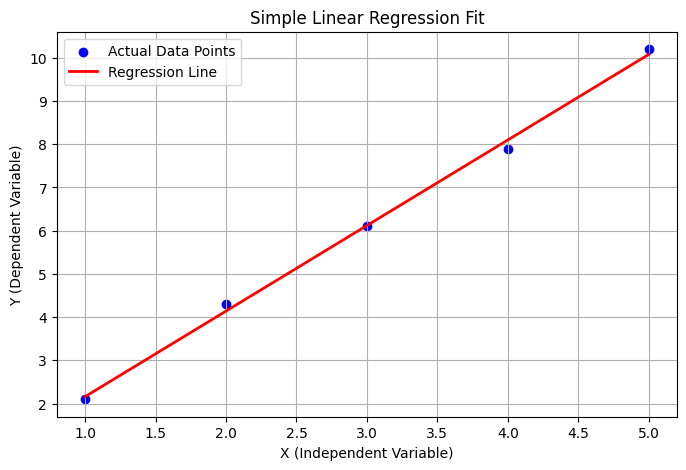

In [ ]:
# Answer of Question 6: Implement a Python program to fit a Simple Linear Regression model to the following sample data:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Define the sample data
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1) # Reshaped to 2D for scikit-learn
Y = np.array([2.1, 4.3, 6.1, 7.9, 10.2])

# 2. Initialize and fit the Simple Linear Regression model
model = LinearRegression()
model.fit(X, Y)

# 3. Calculate predictions for the regression line
Y_pred = model.predict(X)

# 4. Print the results
print(f"Slope (beta_1): {model.coef_[0]:.4f}")
print(f"Intercept (beta_0): {model.intercept_:.4f}")

# 5. Plot the data points and the regression line
plt.figure(figsize=(8, 5))
plt.scatter(X, Y, color='blue', label='Actual Data Points')
plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('X (Independent Variable)')
plt.ylabel('Y (Dependent Variable)')
plt.title('Simple Linear Regression Fit')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Answer of Question 7: Fit a Multiple Linear Regression model on this sample data:

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. Define the sample data
data = {
    'Area': [1200, 1500, 1800, 2000],
    'Rooms': [2, 3, 3, 4],
    'Price': [250000, 300000, 320000, 370000]
}
df = pd.DataFrame(data)

# 2. Fit the Multiple Linear Regression model
X = df[['Area', 'Rooms']]
y = df['Price']
model = LinearRegression()
model.fit(X, y)

# 3. Calculate Variance Inflation Factor (VIF)
# VIF requires an intercept (constant) to be added to the predictor matrix
X_vif = add_constant(X)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# 4. Display Results
print(f"Model Intercept: {model.intercept_:.2f}")
print(f"Coefficients: {dict(zip(X.columns, model.coef_.round(2)))}")
print("\nMulticollinearity Check (VIF):")
print(vif_data[1:]) # Excluding the constant's VIF for clarity

Model Intercept: 103157.89
Coefficients: {'Area': np.float64(63.16), 'Rooms': np.float64(34736.84)}

Multicollinearity Check (VIF):
  Variable       VIF
1     Area  7.736842
2    Rooms  7.736842


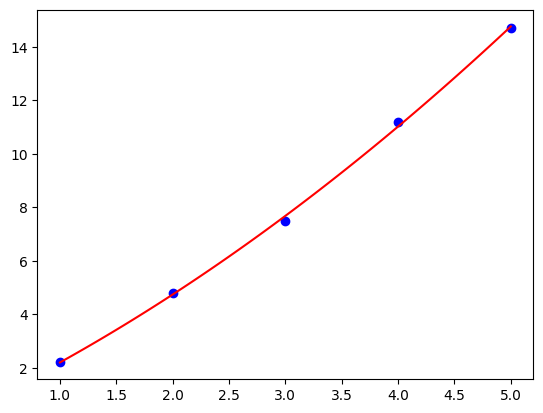

In [ ]:
# Answer of Question 8: Implement polynomial regression on the following data:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 1. Define data
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([2.2, 4.8, 7.5, 11.2, 14.7])

# 2. Polynomial transformation and model fitting
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
model = LinearRegression().fit(X_poly, y)

# 3. Generate smooth curve
X_fit = np.linspace(1, 5, 100).reshape(-1, 1)
y_fit = model.predict(poly.transform(X_fit))

# 4. Plot
plt.scatter(X, y, color='blue')
plt.plot(X_fit, y_fit, color='red')
plt.show()

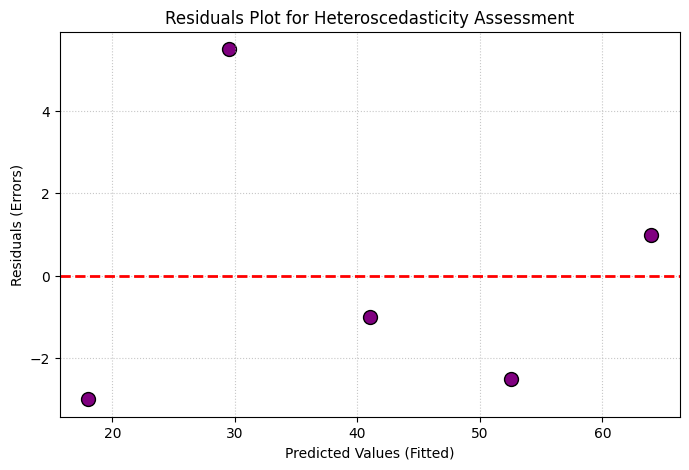

Predicted: 18.0, Residual: -3.0
Predicted: 29.5, Residual: 5.5
Predicted: 41.0, Residual: -1.0
Predicted: 52.5, Residual: -2.5
Predicted: 64.0, Residual: 1.0


In [ ]:
# Answer of Question 9: Create a residuals plot for a regression model trained on this data:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Define the sample data
X = np.array([10, 20, 30, 40, 50]).reshape(-1, 1)
Y = np.array([15, 35, 40, 50, 65])

# 2. Fit the Simple Linear Regression model
model = LinearRegression()
model.fit(X, Y)

# 3. Calculate predicted values and residuals
Y_pred = model.predict(X)
residuals = Y - Y_pred

# 4. Create the Residuals Plot
plt.figure(figsize=(8, 5))
plt.scatter(Y_pred, residuals, color='purple', edgecolor='black', s=100)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)  # Zero error line
plt.xlabel('Predicted Values (Fitted)')
plt.ylabel('Residuals (Errors)')
plt.title('Residuals Plot for Heteroscedasticity Assessment')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# Display values for assessment
for p, r in zip(Y_pred, residuals):
    print(f"Predicted: {p:.1f}, Residual: {r:.1f}")

Question 10: Imagine you are a data scientist working for a real estate company. You need to predict house prices using features like area, number of rooms, and location. However, you detect heteroscedasticity and multicollinearity in your regression model. Explain the steps you would take to address these issues and ensure a robust model.

-> As a data scientist, encountering these issues is common in real estate data because larger, more expensive homes often have more volatile price ranges (heteroscedasticity) and property features like "Area" and "Rooms" are usually tied together (multicollinearity).

Here is the step-by-step plan to fix the model:

1. Addressing Multicollinearity : Multicollinearity makes it hard to tell which feature is actually driving the price.

* Feature Selection: Check the VIF (Variance Inflation Factor). If "Area" and "Rooms" have a VIF > 10, they are redundant. I would likely drop "Rooms" since "Area" is usually a more precise predictor of value.

* Feature Engineering: Instead of using both, I could combine them into a single feature, like "Average Room Size" (Area divided by Rooms).

* Principal Component Analysis (PCA): If I have many correlated features (like number of bathrooms, garage size, and patio size), I can use PCA to merge them into one "Size Factor" that captures the essence of all three without the redundancy.

2. Addressing Heteroscedasticity : In real estate, the model's error often grows as house prices increase (a "fan" shape in the residuals).

* Log Transformation: This is the "gold standard" for house prices. By taking the natural log of the Price, I compress the scale. This often stabilizes the variance and turns the relationship into a percentage-based growth, which is more natural for real estate.

* Weighted Least Squares (WLS): I can assign more weight to smaller, more predictable houses and less weight to the highly volatile luxury mansions so they don't skew the line.

* Use Robust Standard Errors: If I can't fix the spread, I can use "Robust" calculations for my p-values. This doesn't fix the line, but it ensures my statistical conclusions about which features matter remain valid.

3. Final Model Validation

* Check the Residual Plot again: After the log transformation, the residuals should look like a random "cloud" rather than a fan.

* Cross-Validation: I would use k-fold cross-validation to ensure the model isn't just memorizing the training data but can actually predict prices for new listings accurately.